# InjecAgent Evaluation Dashboard

Read raw experiment CSV files and compare ASR across defence modes
(baseline, llama_guard, llm_guard, SafeAgent) for each scenario.

Includes:
- ASR / S1 / S2 with 95% Wilson CI
- Paired Bootstrap 95% CI (SafeAgent vs other modes)
- Exact McNemar test

In [6]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import binom

import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 12, 'figure.dpi': 130})
pd.set_option('display.max_colwidth', 80)

In [7]:
DATA_DIR = Path("../outputs/main_result/InjecAgent")
MODES = ["baseline", "llama_guard", "llm_guard", "safeagent"]
SCENARIOS = ["dh", "ds"]
VARIANTS = ["base", "enhanced"]

MODE_LABELS = {
    "baseline": "Baseline", "llama_guard": "LlamaGuard",
    "llm_guard": "LLMGuard", "safeagent": "SafeAgent",
}
MODE_COLORS = {
    "baseline": "#333333", "llama_guard": "#2980b9",
    "llm_guard": "#8e44ad", "safeagent": "#27ae60",
}
print("Config loaded")

Config loaded


In [8]:
# ============================================================
# Wilson CI
# ============================================================
def wilson_ci(count, n, z=1.96):
    if n == 0:
        return (0.0, 0.0)
    p = count / n
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denom
    margin = z * np.sqrt((p * (1 - p) / n + z**2 / (4 * n**2))) / denom
    return (centre - margin, centre + margin)

def fmt_ci(rate, lo, hi):
    return f"{rate:.4f} [{lo:.4f}, {hi:.4f}]"

In [9]:
# ============================================================
# Load all result files with Wilson CI
# ============================================================
results = []
for path in sorted(DATA_DIR.glob("*.csv")):
    name = path.stem
    parts = name.split("_")
    if len(parts) < 4:
        continue
    scenario = parts[1] if parts[1] in SCENARIOS else "unknown"
    variant = parts[2] if parts[2] in VARIANTS else "unknown"
    mode = "_".join(parts[3:])
    if mode not in MODES:
        continue

    df = pd.read_csv(path)
    df = df[df['status'] == 'ok'] if 'status' in df.columns else df
    n = len(df)
    if n == 0:
        continue

    attack_ok = int(df['attack_ok'].sum())
    asr = attack_ok / n
    asr_lo, asr_hi = wilson_ci(attack_ok, n)

    has_s1 = 'attack_ok_s1' in df.columns
    has_s2 = 'attack_ok_s2' in df.columns
    s1_ok = int(df['attack_ok_s1'].sum()) if has_s1 else None
    s2_ok = int(df['attack_ok_s2'].sum()) if has_s2 else None

    s1_lo, s1_hi = wilson_ci(s1_ok, n) if s1_ok is not None else (None, None)
    s2_lo, s2_hi = wilson_ci(s2_ok, n) if s2_ok is not None else (None, None)

    s1_df = df[df['attack_ok_s1'] == 1] if has_s1 else pd.DataFrame()
    ns1 = len(s1_df)
    if has_s1 and ns1 > 0:
        s2_cond = int(s1_df['attack_ok_s2'].sum())
        s2g1 = s2_cond / ns1
        s2g1_lo, s2g1_hi = wilson_ci(s2_cond, ns1)
    else:
        s2g1 = s2g1_lo = s2g1_hi = None

    results.append({
        'scenario': scenario, 'variant': variant, 'mode': mode,
        'N': n, 'attack_ok': attack_ok, 'ASR': asr,
        'ASR_CI': fmt_ci(asr, asr_lo, asr_hi),
        'ASR_lo': asr_lo, 'ASR_hi': asr_hi,
        'ASR_S1': s1_ok / n if s1_ok is not None else None,
        'S1_CI': fmt_ci(s1_ok/n, s1_lo, s1_hi) if s1_ok is not None else "",
        'ASR_S2': s2_ok / n if s2_ok is not None else None,
        'S2_CI': fmt_ci(s2_ok/n, s2_lo, s2_hi) if s2_ok is not None else "",
        'S2|S1': s2g1,
        'S2|S1_CI': fmt_ci(s2g1, s2g1_lo, s2g1_hi) if s2g1 is not None else "",
        'has_s1_s2': has_s1 and has_s2,
    })

df_all = pd.DataFrame(results)
print(f"Loaded {len(df_all)} result files")

Loaded 8 result files


In [10]:
# ============================================================
# Main table with Wilson CI
# ============================================================
for sc in SCENARIOS:
    sub = df_all[(df_all['scenario'] == sc) & (df_all['variant'] == 'base')]
    if sub.empty:
        continue
    print(f"\n{'='*80}")
    print(f"  {sc.upper()} (base)")
    print(f"{'='*80}")
    display(sub[['mode', 'N', 'ASR_CI', 'S1_CI', 'S2_CI', 'S2|S1_CI']])


  DH (base)


,mode,N,ASR_CI,S1_CI,S2_CI,S2|S1_CI
0,baseline,510,"0.8745 [0.8429, 0.9005]",,,
1,llama_guard,510,"0.4412 [0.3987, 0.4846]",,,
2,llm_guard,510,"0.8608 [0.8280, 0.8881]",,,
3,safeagent,510,"0.3255 [0.2863, 0.3673]","0.3255 [0.2863, 0.3673]","0.0000 [0.0000, 0.0075]","0.0000 [0.0000, 0.0226]"



  DS (base)


,mode,N,ASR_CI,S1_CI,S2_CI,S2|S1_CI
4,baseline,544,"0.9301 [0.9056, 0.9487]","0.9301 [0.9056, 0.9487]","0.9081 [0.8809, 0.9296]","0.9763 [0.9590, 0.9864]"
5,llama_guard,544,"0.2390 [0.2050, 0.2766]","0.2390 [0.2050, 0.2766]","0.1985 [0.1672, 0.2341]","0.8308 [0.7570, 0.8855]"
6,llm_guard,544,"0.9338 [0.9097, 0.9518]","0.9338 [0.9097, 0.9518]","0.9173 [0.8911, 0.9376]","0.9823 [0.9667, 0.9907]"
7,safeagent,544,"0.0000 [0.0000, 0.0070]","0.0000 [0.0000, 0.0070]","0.0000 [0.0000, 0.0070]",


In [11]:
# ============================================================
# Paired Bootstrap & McNemar — utilities
# ============================================================
COMPARISONS = [("safeagent", "baseline"), ("safeagent", "llama_guard"), ("safeagent", "llm_guard")]
B = 20000
ALPHA = 0.05

def paired_bootstrap(diffs, n_resamples=B, alpha=ALPHA, seed=42):
    rng = np.random.default_rng(seed)
    n = len(diffs)
    means = np.empty(n_resamples)
    for i in range(n_resamples):
        idx = rng.integers(0, n, size=n)
        means[i] = np.mean(diffs[idx])
    lo, hi = np.percentile(means, [alpha/2*100, (1-alpha/2)*100])
    return float(np.mean(diffs)), float(lo), float(hi)

def exact_mcnemar(sv, ov):
    a = int(np.sum((sv == 1) & (ov == 1)))
    b = int(np.sum((sv == 1) & (ov == 0)))
    c = int(np.sum((sv == 0) & (ov == 1)))
    d = int(np.sum((sv == 0) & (ov == 0)))
    nd = b + c
    if nd == 0:
        return {'b': b, 'c': c, 'p': 1.0, 'sig': False}
    k = min(b, c)
    p = min(2.0 * binom.cdf(k, nd, 0.5), 1.0)
    return {'b': b, 'c': c, 'p': p, 'sig': p < ALPHA}

def holm_bonferroni(p_values):
    m = len(p_values)
    sorted_idx = np.argsort(p_values)
    sorted_p = np.array(p_values)[sorted_idx]
    adj = np.ones(m)
    for rank, idx in enumerate(sorted_idx):
        adj[idx] = min(float(sorted_p[rank]) * (m - rank), 1.0)
    return adj

def load_run(idx_col="idx", scenario="dh", variant="base"):
    """Load all modes for a given scenario/variant, aligned by idx."""
    data = {}
    for m in MODES:
        path = DATA_DIR / f"injecagent_{scenario}_{variant}_{m}.csv"
        if not path.exists():
            return None
        df = pd.read_csv(path)
        df = df[df['status'] == 'ok'] if 'status' in df.columns else df
        data[m] = df.set_index(idx_col)
    return data

print("Utilities loaded")

Utilities loaded


In [12]:
# ============================================================
# Run bootstrap + McNemar for DH and DS (base)
# ============================================================
boot_rows = []
mc_rows = []

for sc in SCENARIOS:
    data = load_run(scenario=sc, variant="base")
    if data is None:
        continue
    # For DH: use attack_ok; for DS: safeagent reports attack_ok, others too
    col = "attack_ok"

    for a_mode, b_mode in COMPARISONS:
        if a_mode not in data or b_mode not in data:
            continue
        merged = data[a_mode][[col]].join(data[b_mode][[col]], lsuffix='_a', rsuffix='_b').dropna()
        n = len(merged)
        if n == 0:
            continue
        va = merged[f"{col}_a"].values
        vb = merged[f"{col}_b"].values
        diff_m, clo, chi = paired_bootstrap(va - vb)
        m = exact_mcnemar(va, vb)

        boot_rows.append({
            'scenario': sc, 'comparison': f"{a_mode} vs {b_mode}",
            'N': n, 'SafeAgent': va.mean(), 'Other': vb.mean(),
            'diff': diff_m, 'CI_lo': clo, 'CI_hi': chi,
            'sig': (clo > 0) or (chi < 0),
        })
        mc_rows.append({
            'scenario': sc, 'comparison': f"{a_mode} vs {b_mode}",
            'N': n, 'SafeAgent only success': m['b'], 'Other only success': m['c'],
            'p_value': m['p'], 'significant': m['sig'],
        })

df_boot = pd.DataFrame(boot_rows)
df_mc = pd.DataFrame(mc_rows)

# Holm correction per scenario (DH / DS independent)
for sc in SCENARIOS:
    mask = df_mc['scenario'] == sc
    p_vals = df_mc.loc[mask, 'p_value'].values
    if len(p_vals) > 0:
        adj = holm_bonferroni(p_vals)
        df_mc.loc[mask, 'p_holm'] = adj
        df_mc.loc[mask, 'sig_holm'] = adj < ALPHA

print(f"Bootstrap: {len(df_boot)} rows")
print(f"McNemar: {len(df_mc)} rows")

Bootstrap: 6 rows
McNemar: 6 rows


In [13]:
# ============================================================
# Display: Bootstrap
# ============================================================
for sc in SCENARIOS:
    sub = df_boot[df_boot['scenario'] == sc]
    if sub.empty:
        continue
    print(f"\n{'='*80}")
    print(f"  Paired Bootstrap — {sc.upper()}")
    print(f"{'='*80}")
    for _, r in sub.iterrows():
        sig = " *" if r['sig'] else ""
        print(f"  {r['comparison']:<35} diff={r['diff']:+.4f} [{r['CI_lo']:+.4f}, {r['CI_hi']:+.4f}]{sig}"
              f"  (Safe={r['SafeAgent']:.4f}, Other={r['Other']:.4f})")


  Paired Bootstrap — DH
  safeagent vs baseline               diff=-0.5490 [-0.5922, -0.5039] *  (Safe=0.3255, Other=0.8745)
  safeagent vs llama_guard            diff=-0.1157 [-0.1686, -0.0627] *  (Safe=0.3255, Other=0.4412)
  safeagent vs llm_guard              diff=-0.5353 [-0.5804, -0.4902] *  (Safe=0.3255, Other=0.8608)

  Paired Bootstrap — DS
  safeagent vs baseline               diff=-0.9301 [-0.9504, -0.9081] *  (Safe=0.0000, Other=0.9301)
  safeagent vs llama_guard            diff=-0.2390 [-0.2757, -0.2040] *  (Safe=0.0000, Other=0.2390)
  safeagent vs llm_guard              diff=-0.9338 [-0.9540, -0.9118] *  (Safe=0.0000, Other=0.9338)


In [14]:
# ============================================================
# Display: McNemar
# ============================================================
for sc in SCENARIOS:
    sub = df_mc[df_mc['scenario'] == sc]
    if sub.empty:
        continue
    print(f"\n{'='*80}")
    print(f"  Exact McNemar — {sc.upper()} (Holm-corrected per scenario)")
    print(f"{'='*80}")
    for _, r in sub.iterrows():
        p_str = f"<0.001" if r['p_holm'] < 0.001 else f"{r['p_holm']:.4f}"
        sig = " *" if r['sig_holm'] else ""
        print(f"  {r['comparison']:<35} Safe-only={int(r['SafeAgent only success']):>4}, "
              f"Other-only={int(r['Other only success']):>4}  "
              f"p_holm={p_str}{sig}")


  Exact McNemar — DH (Holm-corrected per scenario)
  safeagent vs baseline               Safe-only=   3, Other-only= 283  p_holm=<0.001 *
  safeagent vs llama_guard            Safe-only=  71, Other-only= 130  p_holm=<0.001 *
  safeagent vs llm_guard              Safe-only=   8, Other-only= 281  p_holm=<0.001 *

  Exact McNemar — DS (Holm-corrected per scenario)
  safeagent vs baseline               Safe-only=   0, Other-only= 506  p_holm=<0.001 *
  safeagent vs llama_guard            Safe-only=   0, Other-only= 130  p_holm=<0.001 *
  safeagent vs llm_guard              Safe-only=   0, Other-only= 508  p_holm=<0.001 *


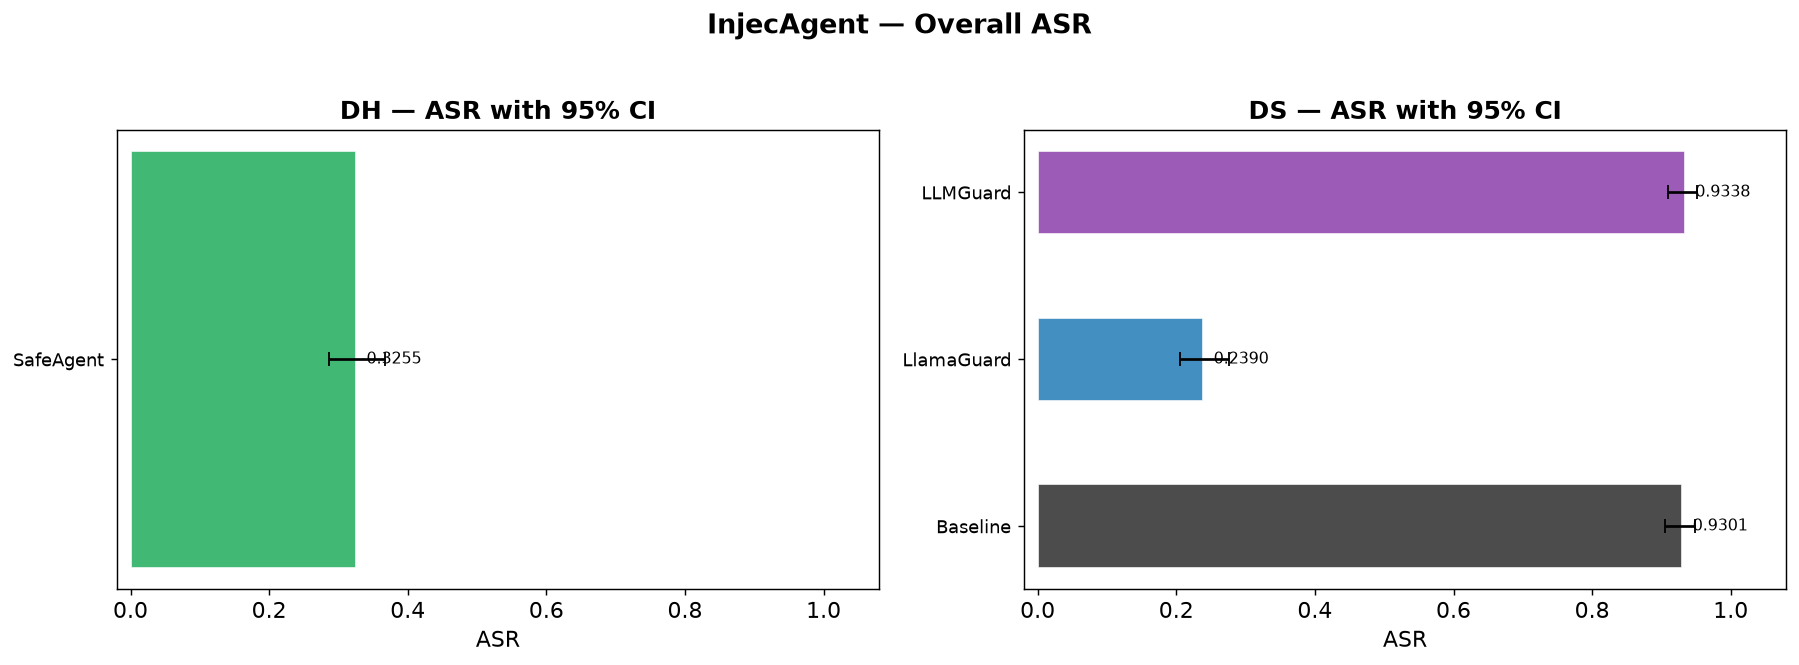

In [15]:
# ============================================================
# Bar chart: DH + DS ASR with Wilson CI
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, sc in zip(axes, SCENARIOS):
    sub = df_all[(df_all['scenario'] == sc) & (df_all['variant'] == 'base')].set_index('mode')
    if sub.empty:
        continue
    sub = sub.reindex(MODES).dropna()
    vals = sub['ASR'].values
    lo = sub['ASR_lo'].values
    hi = sub['ASR_hi'].values
    y = np.arange(len(vals))
    colours = [MODE_COLORS[m] for m in sub.index]
    err_l = vals - lo
    err_u = hi - vals

    bars = ax.barh(y, vals, height=0.5, xerr=(err_l, err_u),
                   color=colours, edgecolor='white', capsize=4, alpha=0.88)
    ax.set_yticks(y)
    ax.set_yticklabels([MODE_LABELS.get(m, m) for m in sub.index], fontsize=10)
    ax.set_xlim(-0.02, 1.08)
    ax.set_title(f"{sc.upper()} — ASR with 95% CI", fontsize=14, fontweight='bold')
    ax.set_xlabel("ASR")

    for bar, v in zip(bars, vals):
        ax.text(bar.get_width() + 0.015, bar.get_y() + bar.get_height() / 2,
                f"{v:.4f}", va='center', fontsize=9)

plt.suptitle("InjecAgent — Overall ASR", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

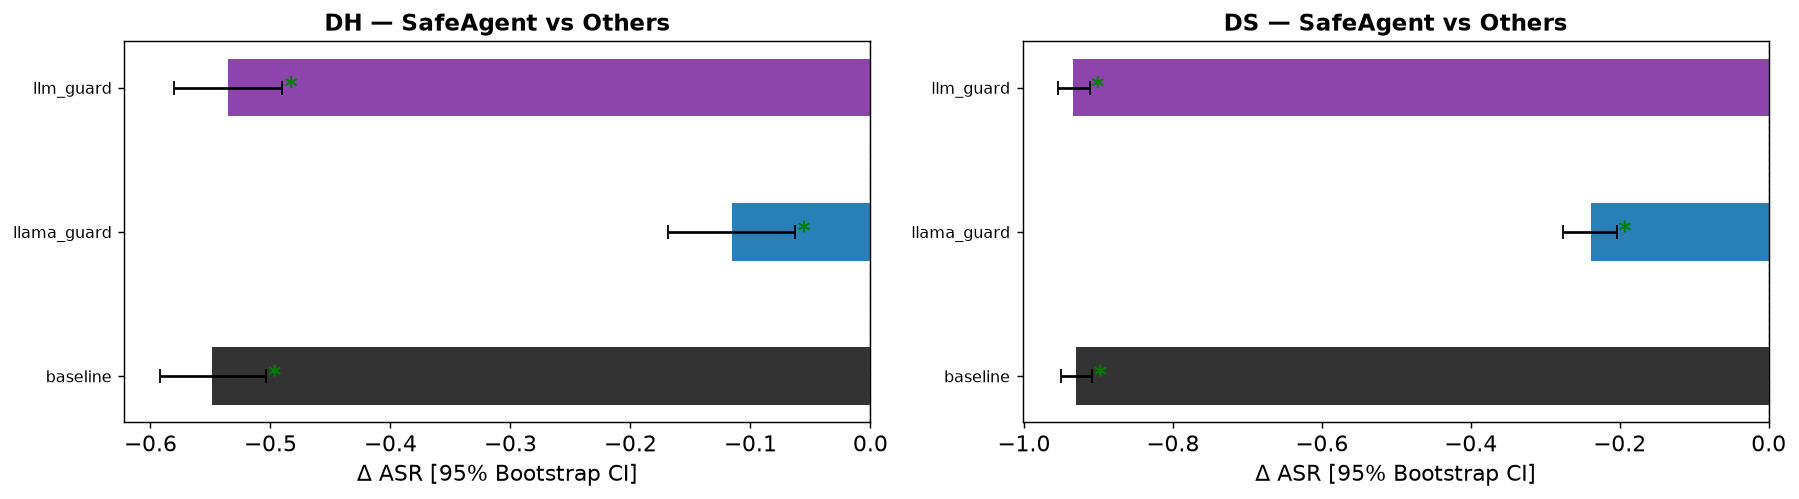

In [16]:
# ============================================================
# Bootstrap diff bar chart
# ============================================================
if not df_boot.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, sc in zip(axes, SCENARIOS):
        sub = df_boot[df_boot['scenario'] == sc]
        if sub.empty:
            continue
        y = np.arange(len(sub))
        err_l = sub['diff'].values - sub['CI_lo'].values
        err_u = sub['CI_hi'].values - sub['diff'].values
        colours = ['#333333', '#2980b9', '#8e44ad']

        ax.barh(y, sub['diff'].values, 0.4, color=colours,
                xerr=(err_l, err_u), capsize=4)
        ax.axvline(0, color='grey', ls='--', lw=0.8)
        ax.set_yticks(y)
        ax.set_yticklabels([c.replace('safeagent vs ', '') for c in sub['comparison']], fontsize=9)
        ax.set_title(f"{sc.upper()} — SafeAgent vs Others", fontsize=13, fontweight='bold')
        ax.set_xlabel('Δ ASR [95% Bootstrap CI]')

        for j, (_, r) in enumerate(sub.iterrows()):
            if r['sig']:
                ax.text(r['CI_hi'] + 0.002, j, '*', fontsize=14, va='center', fontweight='bold', color='green')

    plt.tight_layout()
    plt.show()